In [ ]:
!pip install spatialdata squidpy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch.utils.data import DataLoader

import scanpy as sc
from tqdm import tqdm
import numpy as np

import csv
import os
import sys
from filelock import FileLock

os.chdir("/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis")
cwd = os.getcwd()
print(cwd)

sys.path.append("./")
import Modified_Steamboat as MS

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis


In [9]:
ad = sc.read_h5ad("../Breast_Cancer/all_embeddings_V2.h5ad")

In [ ]:
X = ad.X.toarray()
morpho = ad.obsm['UNI']
ad.obsm['concat_UNI'] = np.concatenate([morpho, X], axis=-1)

In [11]:
ad.write_h5ad("../Breast_Cancer/all_embeddings_V3.h5ad")

In [12]:
ad = sc.read_h5ad("../Mouse_Brain/all_embeddings_V2.h5ad")

In [ ]:
X = ad.X.toarray()
morpho = ad.obsm['UNI']
ad.obsm['concat_UNI'] = np.concatenate([morpho, X], axis=-1)

In [14]:
ad.write_h5ad("../Mouse_Brain/all_embeddings_V3.h5ad")

## Breast Cancer

In [ ]:
ad = sc.read_h5ad("../Breast_Cancer/all_embeddings.h5ad")

In [ ]:
HE_modal = 'UNI'
adata = sc.read_h5ad("../Breast_Cancer/all_embeddings.h5ad")

adata.obsm['p_Morpho_Embedding'] = adata.obsm[HE_modal].copy()

adata = MS.prep_adatas(adata, norm=True, log1p=True)
dataset = MS.make_dataset(adata, sparse_graph=True)

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/Modified_Steamboat/dataset.py:37: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/Modified_Steamboat/dataset.py:46: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, n_neighs=n_neighs)


In [ ]:
def masking(x: torch.Tensor, entry_masking_rate: float):
    """Masking the dataset

    :param x: input data
    :param mask_rate: masking rate
    :param masking_method: full matrix or feature-wise masking
    :return: masked data
    """
    out_x = x.clone()
    if entry_masking_rate > 0.:
        random_mask = torch.rand(x.shape, device=x.device) < entry_masking_rate
        out_x.masked_fill_(random_mask, 0.)
    return out_x

In [ ]:
for mn in tqdm(['UNI', 'NOMORPHO', 'NOISE']):
  save_dir = "/content/drive/MyDrive/Thesis/Projects/Data/Trained_Weights"
  MS.set_random_seed(20)
  model = MS.model.Steamboat(
      features=len(adata.var_names.tolist()),
      morpho_features=adata.obsm['p_Morpho_Embedding'].shape[1],
      n_heads=64,
      n_scales=2
      )
  model = model.to(device)
  model.load_state_dict(
          torch.load(
              os.path.join(save_dir,f'MS_BC_MR_0.3_Seed_2_{mn}.pth'), map_location=torch.device(device),weights_only=True
              ), strict=False
              )
  for i, (x, m, adj_list) in enumerate(dataset):
    print('slide: ', i+1)
    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)
    masked_x = masking(x, 0.3)

    with torch.no_grad():
      x_recon, alpha, local_attnp, local_attnm = model(adj_list, masked_x, m, masked_x, m, get_details=True)
  ad.obsm[f'Modified_Steamboat_{mn}'] = local_attnm.cpu().numpy()

  0%|          | 0/3 [00:00<?, ?it/s]

slide:  1


 33%|███▎      | 1/3 [00:20<00:41, 20.60s/it]

slide:  1


 67%|██████▋   | 2/3 [00:33<00:16, 16.16s/it]

slide:  1


100%|██████████| 3/3 [00:45<00:00, 15.12s/it]


... UMAP ...


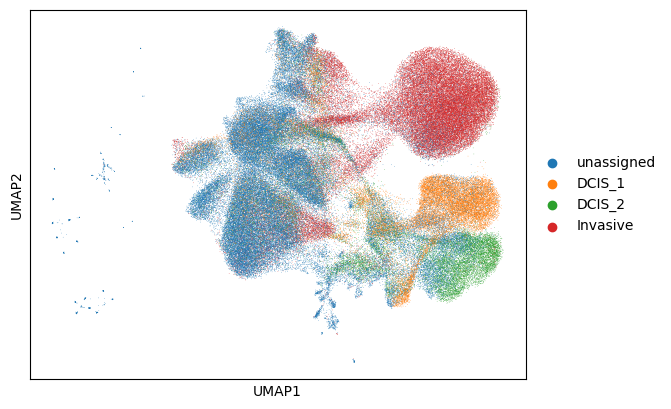

In [ ]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_UNI'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


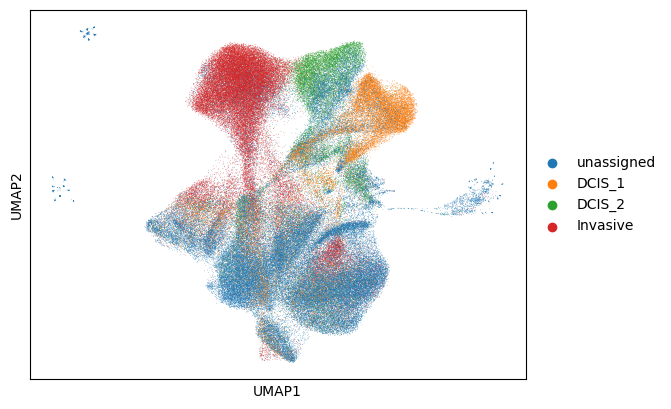

In [ ]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_NOISE'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


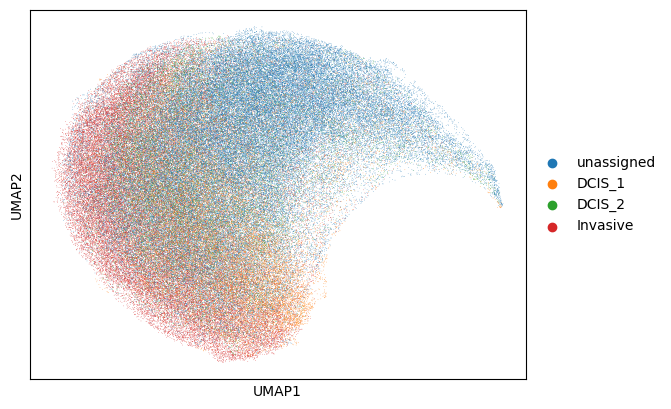

In [ ]:
from sklearn.decomposition import PCA

ad_m = ad.copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_NOMORPHO'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

In [ ]:
ad.write_h5ad("../Breast_Cancer/all_embeddings_V1.h5ad")

## Mouse Brain

In [ ]:
ad = sc.read_h5ad("../Mouse_Brain/all_embeddings.h5ad")

In [ ]:
HE_modal = 'UNI'
adata = sc.read_h5ad("../Mouse_Brain/all_embeddings.h5ad")

adata.obsm['p_Morpho_Embedding'] = adata.obsm[HE_modal].copy()

adata = MS.prep_adatas(adata, norm=True, log1p=True)
dataset = MS.make_dataset(adata, sparse_graph=True)

/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/Modified_Steamboat/dataset.py:37: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/content/drive/MyDrive/Thesis/Projects/Data/Master_Thesis/Modified_Steamboat/dataset.py:46: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, n_neighs=n_neighs)


In [ ]:
def masking(x: torch.Tensor, entry_masking_rate: float):
    """Masking the dataset

    :param x: input data
    :param mask_rate: masking rate
    :param masking_method: full matrix or feature-wise masking
    :return: masked data
    """
    out_x = x.clone()
    if entry_masking_rate > 0.:
        random_mask = torch.rand(x.shape, device=x.device) < entry_masking_rate
        out_x.masked_fill_(random_mask, 0.)
    return out_x

In [ ]:
for mn in ['UNI', 'NOMORPHO', 'NOISE']:
  save_dir = "/content/drive/MyDrive/Thesis/Projects/Data/Trained_Weights"
  MS.set_random_seed(20)
  model = MS.model.Steamboat(
      features=len(adata.var_names.tolist()),
      morpho_features=adata.obsm['p_Morpho_Embedding'].shape[1],
      n_heads=64,
      n_scales=2
      )
  model = model.to(device)
  model.load_state_dict(
          torch.load(
              os.path.join(save_dir,f'MS_MB_MR_0.3_Seed_2_{mn}.pth'), map_location=torch.device(device),weights_only=True
              ), strict=False
              )
  for i, (x, m, adj_list) in enumerate(dataset):
    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)
    masked_x = masking(x, 0.3)

    with torch.no_grad():
      x_recon, alpha, local_attnp, local_attnm = model(adj_list, masked_x, m, masked_x, m, get_details=True)

  ad.obsm[f'Modified_Steamboat_{mn}'] = local_attnm.cpu().numpy()

... UMAP ...


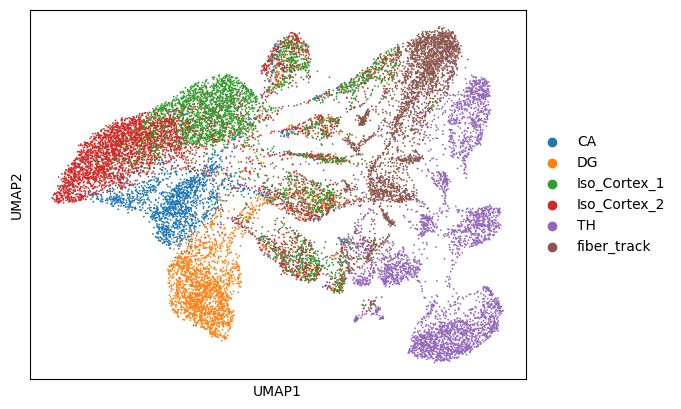

In [ ]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_UNI'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


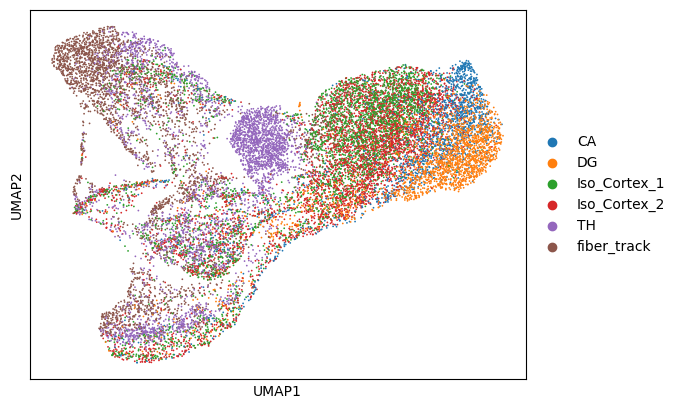

In [ ]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_NOISE'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

... UMAP ...


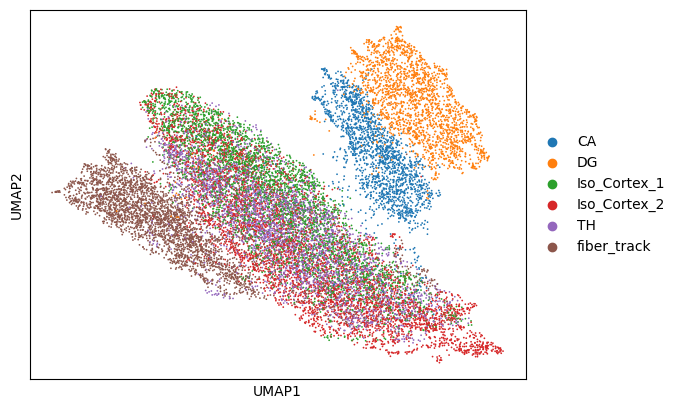

In [ ]:
from sklearn.decomposition import PCA

mask = ad.obs['annotation'] == 'unassigned'
ad_m = ad[~mask].copy()

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(ad_m.obsm[f'Modified_Steamboat_NOMORPHO'])
ad_m.obsm['reduced_dim_embedding'] = X_reduced

print('... UMAP ...')

sc.pp.neighbors(ad_m, use_rep='reduced_dim_embedding', n_neighbors=15)
sc.tl.umap(ad_m)
sc.pl.umap(ad_m, color='annotation', title='')

In [ ]:
ad.write_h5ad("../Mouse_Brain/all_embeddings_V1.h5ad")